In this notebook we progress from Fourier Series discussed in the previous notebook [FourierSeries.ipynb](FourierSeries.ipynb) to the *Fourier Transform*. 

We will first cover some of the theoretical background, and then illustrate some applications of Fourier Transforms to audio processing.


# Contents 
 0. Intro. Video
 1. Fourier Transform 
 2. Background to the Fourier Transform
 3. Exploring the Discrete Fourier Transform
 4. FFT
 5. Audio files
 6. Apply FFT to Audio Files


# Import statements 

In [1]:
import numpy as  np 
import sympy
sympy.init_printing()
import matplotlib.pyplot as plt
%matplotlib inline

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


# 0. Intro. Video 

An excellent video describing the Fourier Transform can be found [here](https://www.youtube.com/watch?v=spUNpyF58BY).


# 1. Fourier Transform 

##### Fourier Series 

We saw in the [Fourier Series](FourierSeries.ipynb) notebook that the expression for a Fourier Series can be written as:
\begin{eqnarray}
f(x)= \frac{a_0}{2} + \sum\limits_{n=1}^\infty a_n \cos(\frac{n \pi x}{L}) + \sum\limits_{n=1}^\infty b_n \sin(\frac{n \pi x}{L})
\end{eqnarray}   

Using [Euler's formula](https://en.wikipedia.org/wiki/Euler%27s_formula), $e^{ix}=\cos x + i\sin x$, this can be rewritten as 
\begin{eqnarray}
f(x)=\sum\limits_{n=-\infty }^{\infty }c_{n}\cdot e^{\frac {2\pi inx}{P}}
\end{eqnarray}
where the complex coefficients, $c_n$, are given by 
$c_{n}={\frac {1}{P}}\int _{-P/2}^{P/2}s(x)e^{-{\frac {2\pi inx}{P}}}\,dx$

See [here](https://en.wikipedia.org/wiki/Fourier_series) for details of the steps involved to get to this exponential form of the Fourier Series 

##### Fourier Transform 

The Fourier *transform* can be obtained from the Fourier *series* by taking the limit as 
$P\to \infty $, while at the same time taking $n$ so that $n/P\to \xi$, giving:

\begin{eqnarray}
{\hat {f}}(\xi )=\int _{-\infty }^{\infty }f(x)\ e^{-2\pi i\xi x}\,dx.
\end{eqnarray}


The Fourier transform (FT) is an integral transform that converts a function (and/or data) into a form that describes the frequencies present in the original function. 

 

The *discrete* Fourier transform (DFT) transforms a sequence of N numbers 
$\left\{\mathbf {x}_{n}\right\}:=x_{0},x_{1},\ldots ,x_{N-1}$ into another sequence of numbers, 
$\left\{\mathbf {X}_{k}\right\}:=X_{0},X_{1},\ldots ,X_{N-1}$, where ${x}_{n}$ & ${X}_{k}$ can both be complex.

The DFT is written 

$X_{k}=\sum _{n=0}^{N-1}x_{n}\cdot e^{-{\frac {2\pi i}{N}}kn}$
 
The inverse discrete Fourier transform (IDFT) has a very similar form 

$x_{n}=\frac{1}{N}\sum _{k=0}^{N-1}X_{k}\cdot e^{+{\frac {2\pi i}{N}}kn}$
 

See 
 - https://en.wikipedia.org/wiki/Fourier_transform
 - https://en.wikipedia.org/wiki/Discrete_Fourier_transform
 - https://www.kaggle.com/code/tedipetkova/fourier-transform/notebook


# 2. Background to the F.T. 

## 2.1 Introduction & Interpretation

An excellent video describing the Fourier Transform can be found [here](https://www.youtube.com/watch?v=spUNpyF58BY).


## 2.2 Understanding the Behavior of the FT

We will use the example function 
$
f(x) = 
\begin{cases}
  0, \hspace{2cm} \text{if } x \lt -1 \\
  \cos\left(6\pi x\right), \hspace{0.6cm} \text{if } -1 \leq x \leq 1 \\
  0, \hspace{2cm} \text{if } x \gt 1 
\end{cases}
$

I.e. It's just a cosine wave that is set to zero above $+1$ and below $-1$.

Plotting below using sympy we see that it oscillates 3 times in 1 second: I.e. it has a frequency of 3 Hz.

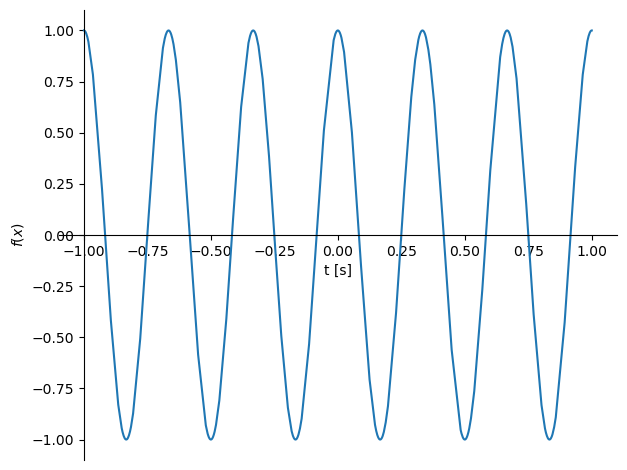

In [2]:
import sympy
x = sympy.Symbol('x')
interval = (x, -1,1)
p2 = sympy.plot( sympy.cos(6*sympy.pi*x ), interval, show=True, xlabel="t [s]", axis_center=(-1,0))

##### Components of the FT 
Now we consider the different components of the FT equation as applied to $f(x)=\cos\left(6\pi x\right)$ to try and get some insight into its behavior.

\begin{eqnarray}
{\hat {f}}(\xi ) &=& \int _{-\infty }^{\infty }f(x) \exp^{-2\pi i\xi x}\,dx.
\\
                 &=& \int _{-\infty }^{\infty }f(x) \left(\cos \left(2\pi \xi x\right) - i\sin \left(2\pi \xi x\right) \right)\,dx.
\\
                 &=& \int _{-1 }^{+1 } \cos\left(6\pi x\right)  \left(\cos \left(2\pi \xi x\right) - i\sin \left(2\pi \xi x\right) \right)\,dx.                 
\\   
                &=& \int _{-1 }^{+1 }R(x,\xi)\,dx - i \int _{-1 }^{+1 }I(x,\xi)\,dx 
\end{eqnarray}
where we have split the integral up into real and imaginary parts, with the real integrand, $R(x,\xi)$, given by 

$R(x,\xi) =\cos\left(6\pi x\right)  \cos \left(2\pi \xi x\right)$

and the imaginary integrand, $I(x,\xi)$, given by 

$I(x,\xi) = \cos\left(6\pi x\right)  \sin \left(2\pi \xi x\right)$.

We define these as sympy functions in the cell below...

In [3]:
x = sympy.Symbol('x')
xi = sympy.Symbol('xi')

def f(x):
    return sympy.cos(6*sympy.pi*x )

# The two integrands used within the fourier transform 
def R(x, xi, f):
    return f(x) * sympy.cos(2*sympy.pi*xi*x ) 
def I(x, xi, f):
    return f(x) * sympy.sin(2*sympy.pi*xi*x ) 

# Functions to INTEGRATE R & I 
def intR(xi,f): 
    return sympy.integrate( R(x, xi,f) , (x,-1,1) )
def intI(xi,f): 
    return sympy.integrate( I(x, xi,f) , (x,-1,1) )


##### Frequencies

The FT picks out different *frequencies*, $\xi$. 

In the plot below, we plot `R(x, xi)`, controlling the value of $\xi$ using a *slider*. 

We also calculate the value of its integral, $\int _{-1 }^{+1 }R(x,\xi)\,dx$, and print that in the title. 

N.B. We know from the above plot that the function appears to have a frequency of 3 Hz. As such, we can guess that the results for ${\hat {f}}(\xi = 3)$ and ${\hat {f}}(\xi\,\,!= 3)$ should be quite different. 
 
Playing around with the value of $\xi$, we find that ... 
 - The plot for $R(x, \xi=3)$ is entirely above the x-axis. As a result, it's integral is large. 
 - For values of $\xi$ significantly different from $3$ (e.g. $R(x, \xi=5)$), we see that significant portions of $R$ are above and below the x-axis. Hence it's positive and negative integral components significantly cancel-out, and the total integral is much smaller. 
 - This means that the FT will have large values close to $\xi=3$, and small (or zero) values elsewhere. 

In [4]:
import matplotlib.pyplot as plt
import numpy as np
from ipywidgets import interact

def plot_R(xi_):
    """ 
    Plotting $x(t) =  C\cos{\left(\omega t\right)} + D\sin{\left(\omega t\right)} $
     - Will be called using ipywidgets.interact 
    
    E: # Cosine amplitude
    omega: # The equation frequency
    delta: # Phase offset 
    """
    
    # Plot real integrand, with xi_ being controlled by slider
    interval = (x, -1,1)
    integral = intR(xi_,f).evalf()
    title = f'Plotting R(x, {xi}={xi_:.3f}, f={f(x)}) \nNB: $\int$ R(x, {xi}={xi_:.3f}) dx={integral:.3f}' 
    p  =sympy.plot( R(x,xi_,f) ,   
                    interval, 
                    title=title, 
                    show=False,                     
                    xlim=[-1,1], ylim=[-2,2])
    p.show()

# Call the plot function using the ipywidgets `interact` function
_ = interact(plot_R, xi_=(0.1,10,0.1))




interactive(children=(FloatSlider(value=5.0, description='xi_', max=10.0, min=0.1), Output()), _dom_classes=('…

Now we compare a couple of different functions, 

$f_6(x)  = \cos\left(6\pi x\right)$

and 

$f_{10}(x)  = \cos\left(10\pi x\right)$

Again we plot the values of `R(x, xi)`, controlling the value of xi with a slider.

This time we see that the values of xi for which `R` is primarily above the x-axis (and its integral is large) *differs* for $f_6$ and $f_{10}$:
 - For $f_6$, the integral of `R` is maximized around $\xi=3$
 - For $f_{10}$, the integral of `R` is maximized around $\xi=5$

The integral picks out the important frequency (or frequencies) of the underlying function. 

In [5]:
# Imports 
import matplotlib.pyplot as plt
import numpy as np
from ipywidgets import interact
import sympy

# Sympy Symbols 
x = sympy.Symbol('x')
xi = sympy.Symbol('xi')

# The two functions we are going to investigate ...
def f6(x): 
    return sympy.cos(6*sympy.pi*x )
def f10(x): 
    return sympy.cos(10*sympy.pi*x )

def plot_R_comparison(xi_):
    """ 
    Plotting ...
     - Will be called using ipywidgets.interact 
    
    E: # Cosine amplitude
    omega: # The equation frequency
    delta: # Phase offset 
    """
    
    # Plot real integrand, with xi_ being controlled by slider
    interval = (x, -1,1)

    integral = intR(xi_,f6).evalf()
    label = f'R(x, {xi}={xi_:.3f}, f={f6(x)}) :\t $\int$ R={integral:.3f}' 
    p6  =sympy.plot( R(x,xi_,f6) ,   
                    interval, 
                    label=label, 
                    show=False,    
                    legend=True,
                    xlim=[-1,1], ylim=[-2,2])

    integral = intR(xi_,f10).evalf()
    label = f'R(x, {xi}={xi_:.3f}, f={f10(x)}) : $\int$ R={integral:.3f}' 
    p10  =sympy.plot( R(x,xi_,f10) ,   
                    interval, 
                    label=label, 
                    show=False,                     
                    legend=True,
                    xlim=[-1,1], ylim=[-2,2])
    p6.append(p10[0])
    p6.show()
    
# Call the plot function using the ipywidgets `interact` function
_ = interact(plot_R_comparison, xi_=(0.1,10,0.1))




interactive(children=(FloatSlider(value=5.0, description='xi_', max=10.0, min=0.1), Output()), _dom_classes=('…

# Exercise (A) 

Above we calculated and plotted the values of $R(x,xi)$ using a function named `plot_R_comparison`. 

Adapt this function to perform the same plot but for the *imaginary* part, `I(x,xi)`

What do you notice about the value of the integral? 

##### Integrals 
We defined the integrals of `R` & `I` above. 

We can use these expressions to explicitly evaluate the integrals ...

We know that the integral of `I` is zero (for our cosine functions), so for these cosine functions, the integral of `R` is the Fourier Transform, ${\hat {f}}(\xi )$.

In [8]:
%%time
# Evaluating explicit values of xi allows us to evaluate the components of the Fourier Transform
import numpy as np 
import matplotlib.pyplot as plt

# Set up an array of \xi values 
xi_array = np.arange(1,6,0.01)

# Evaluate the integral of R for f6 = cos(6*pi*x)
intR6_array = [intR(_,f6).evalf() for _ in xi_array]
# Evaluate the integral of R for f10 = cos(10*pi*x)
intR10_array = [intR(_,f10).evalf() for _ in xi_array]

CPU times: user 1min 24s, sys: 524 ms, total: 1min 24s
Wall time: 1min 24s


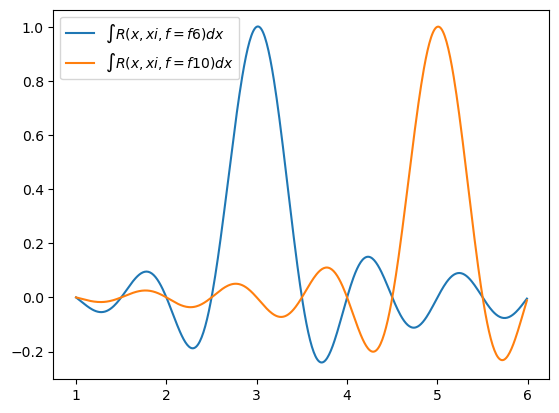

In [9]:
plt.plot(xi_array,intR6_array, label='$\int R(x,xi,f=f6)dx $')
plt.plot(xi_array,intR10_array, label='$\int R(x,xi,f=f10)dx $')
plt.legend() 
plt.show()

# Width in Frequency-Space ~ 1 / (Width in Physical Space}

Consider the "box" function, 
\begin{eqnarray}
f(x) = 
\begin{cases}
  0, \text{if } x \lt -d \\
  1, \text{if } -d \leq x \leq d \\
  0, \text{if } x \gt d 
\end{cases}
\end{eqnarray}

We can analytically perform this integral to find ... 
\begin{eqnarray}
{\hat {f}}(\xi ) &=& \int _{-\infty }^{\infty }f(x) e^{-2\pi i\xi x}\,dx. \\
                 &=& \int _{-d }^{d } 1 \cdot e^{-2\pi i\xi x}\,dx. \\
                 &=& \left[ \frac{e^{-2\pi i\xi x}}{-2\pi i\xi} \right]_{x=-d}^{x=+d} \\ 
                 &=& \frac{1}{-2\pi i\xi} \left( e^{-2\pi i\xi d} - e^{2\pi i\xi d}\right) \\ 
                 &=& \frac{\sin 2\pi \xi d}{\pi \xi}
\end{eqnarray}

where $e^{ix}=\cos x + i\sin x$, $\implies$ $e^{2\pi i\xi d}=\cos 2\pi \xi d + i\sin 2\pi \xi d$ and $e^{-2\pi i\xi d}=\cos 2\pi \xi d - i\sin 2\pi \xi d$, giving $e^{-2\pi i\xi d} - e^{2\pi i\xi d} = -2i\sin 2\pi \xi d$.

The equation for ${\hat {f}}(\xi )$ has the form of a `sinc` function. 

Plotting this we see that 
 - When the spatial dimenstion, $d$, is *small* ($d=1$), then the FT is *wide*
 - When the spatial dimenstion, $d$, is *large* ($d=10$), then the FT is *narrow*

This is a very general and important characteristics of FTs

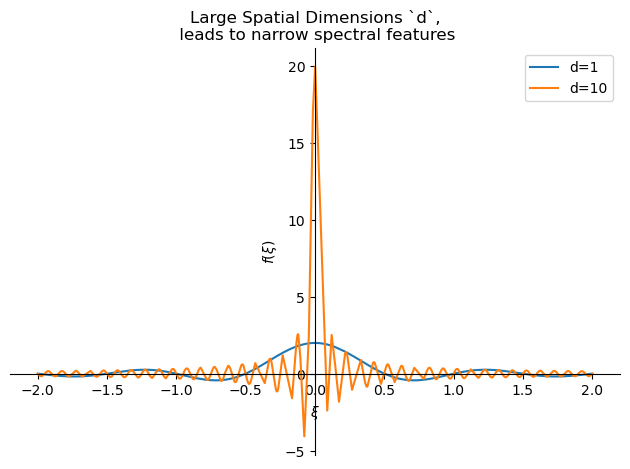

In [45]:
import sympy
xi = sympy.Symbol('xi')
interval = (xi, -2,2)
p1 = sympy.plot( sympy.sin(2*sympy.pi*xi*1)/(sympy.pi*xi), interval, show=False, label="d=1", legend=True, title='Large Spatial Dimensions `d`,\n leads to narrow spectral features')
p10 = sympy.plot( sympy.sin(2*sympy.pi*xi*10)/(sympy.pi*xi), interval, show=False, label="d=10", legend=True)
p1.append(p10[0])
p1.show()

# 3. Exploring the DFT

In practice, the *discrete* FT (DFT) is far more important than the integral version.

The DFT is written 

$X_{k}=\sum _{n=0}^{N-1}x_{n}\cdot e^{-{\frac {2\pi i}{N}}kn}$
 
The DFT is used in a huge number of applications. 

## 3.1  A function to evaluate the DFT

We will start to understand the DFT in more detail by implementing the formula from the formal definition...

In [49]:
def dft1D_base(x, inverse=False, verbose=False):
    """
    Discrete Fourier Transform 1D
    
    x: array
     - data values 
    
    inverse:Boolean
     - If True, perform inverse DFT
     
    """
    N = len(x)
    
    # Set sign & factor depending on whether we are performing DFT or IDFT 
    if inverse: 
        sign   = 1 
        factor = 1/N
    else:
        sign   = -1 
        factor = 1        
    
    X = np.array([])
    for k in range(0, N):                          # Allow calculation of each of the k-components 
        Xk = complex(0, 0)                         # Python has native support for complex numbers
        for n in range(0, N):                      # Summation over n=0 to n=N-1 
            exp = np.exp(sign*2*np.pi*k*n*1j/N)    # Define the exponential
            Xk += complex(x[n]) * exp              # Accumulate the terms for X_k
        X = np.append(X, [factor * Xk])            # Append the final value for X_k
    return X

def dft1D(x,verbose=False):
    return dft1D_base(x, inverse=False, verbose=verbose) 

def idft1D(X,verbose=False):
    return dft1D_base(X, inverse=True, verbose=verbose) 

Given a simple input array, the returned DFT is an equal length array of complex numbers...

In [50]:
x = np.array([1,2,3,4,5])
dft1D(x)

array([15. +0.j        , -2.5+3.4409548j , -2.5+0.81229924j,
       -2.5-0.81229924j, -2.5-3.4409548j ])

## 3.2 Create Data 
Let's create a function that will create data out of multiple sine waves added together.
 - We'll use this to generate some signals ...

In [51]:
def generate_sinusoids( amplitudes, frequencies, phase_shifts, t=np.arange(0,1,0.01)):
    """
    Create data out of multiple cosine signals added together
    
    Assumes the *phase-shift* form for the basic signal: 
    y(t) = A cos( \omega t + \delta)$
    
    where 
    A = Amplitude, omega=frequency, and delta=phase-offset
    
    inputs:
    ------------
    amplitudes:
    frequencies:
    phase_shifts:
    t:
    
    returns:
    ------------
    x:
    signal:

    """
    assert len(amplitudes)==len(frequencies)==len(phase_shifts)

    signal = np.zeros(len(t))
    for amp,freq,phase_shift in zip(amplitudes, frequencies, phase_shifts):
        signal += amp*np.sin(freq*t*2*np.pi + phase_shift)
        
    return t, signal


def generate_signal(amplitudes, 
                    frequencies, 
                    phase_shifts,
                    sample_freq_hertz = 44100,    # Default 44100 samples per second
                    duration_seconds = 3          # Default duration of 3 seconds
                   ):
    
    # Generate time array
    t = np.arange(0, duration_seconds, 1/sample_freq_hertz)
    
    # Generate a signal 
    return generate_sinusoids(amplitudes, frequencies, phase_shifts, t=t)
                                    

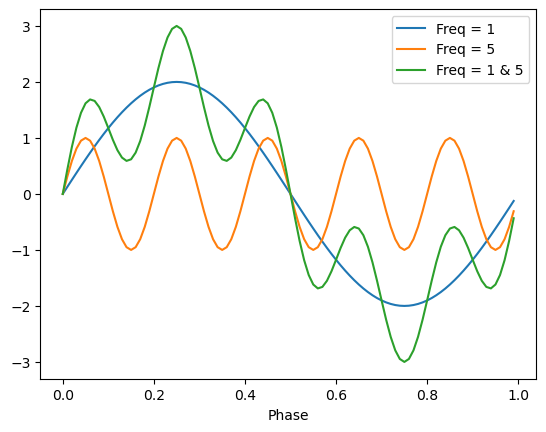

In [52]:
# Demonstrate usage of underlying `generate_sinusoids` function
plt.plot(*generate_sinusoids( [2], [1], [0] ), label='Freq = 1')
plt.plot(*generate_sinusoids( [1], [5], [0] ), label='Freq = 5')
plt.plot(*generate_sinusoids( [2,1], [1,5], [0,0] ), label='Freq = 1 & 5')
plt.xlabel('Phase')
plt.legend()
plt.show()


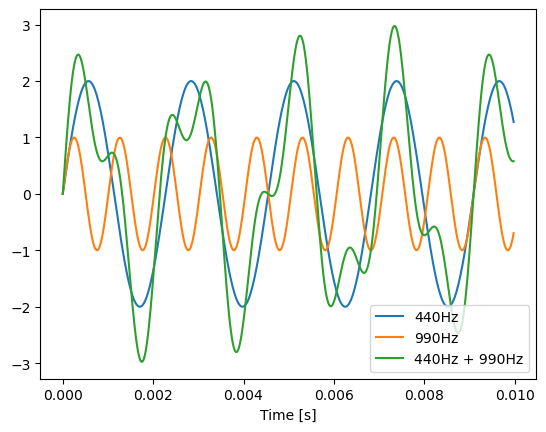

In [53]:
# Demonstrate usage of `generate_signal` function
plt.plot(*generate_signal( [2], [440], [0] , duration_seconds=0.01 ), label='440Hz')
plt.plot(*generate_signal( [1], [990], [0] , duration_seconds=0.01), label='990Hz')
plt.plot(*generate_signal( [2,1], [440,990], [0,0] , duration_seconds=0.01 ), label='440Hz + 990Hz')
plt.xlabel('Time [s]')
plt.legend()
plt.show()

## 3.3 DFT of Data 
Let's generate some data and analyze it using the DFT.

Some points to note:
 - We don't pass the time-data to the DTF, so it has no idea of the *scale* of the data: you have to sort out the x-axis yourself: i.e. you need to use your knowledge of the input signal sampling-rate to generate a frequency vector for the output. 
 - 

In [54]:
# Generate the data 
freqs = [440,990]
t, signal = generate_signal( [2,1], freqs, [0,0], duration_seconds=0.1)
print(f' signal.size = {signal.size}')

# Take the DFT
dft = dft1D(signal)
N = dft.size 
print(f' dft.size = {dft.size}')

# We will need a frequency vector ...
sample_freq_hertz = 44100
f = np.linspace(0, sample_freq_hertz, signal.size)
f

 signal.size = 4410
 dft.size = 4410


array([0.00000000e+00, 1.00022681e+01, 2.00045362e+01, ...,
       4.40799955e+04, 4.40899977e+04, 4.41000000e+04])

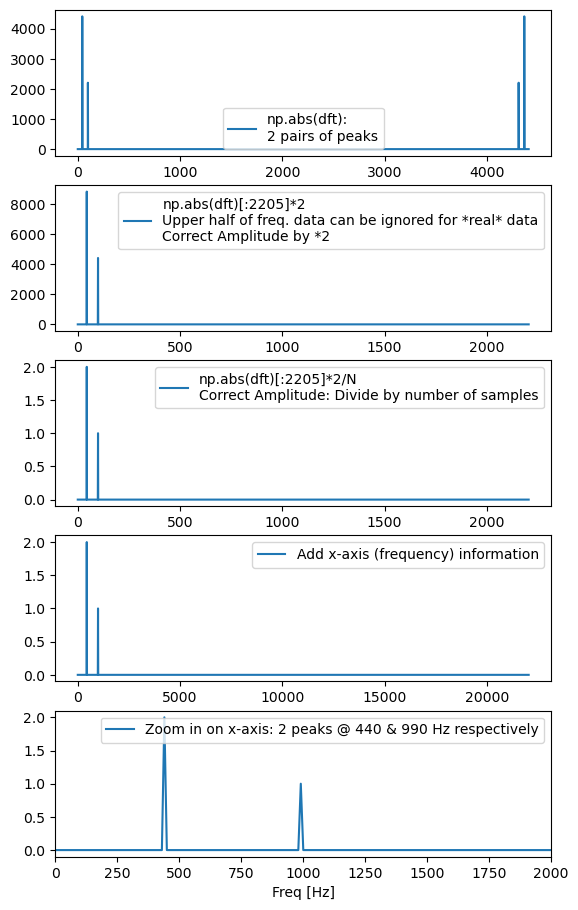

In [55]:
# Make some plots ...
fig, (ax1, ax2, ax3, ax4, ax5) = plt.subplots(5)
fig.set_figheight(11)

label = 'np.abs(dft):\n2 pairs of peaks'
ax1.plot(np.abs(dft), label=label)
ax1.legend()

label = f'np.abs(dft)[:{N//2}]*2\nUpper half of freq. data can be ignored for *real* data\nCorrect Amplitude by *2'
ax2.plot(np.abs(dft)[:N//2]*2, label=label)
ax2.legend()

label = f'np.abs(dft)[:{N//2}]*2/N\nCorrect Amplitude: Divide by number of samples'
ax3.plot(np.abs(dft)[:N//2]*2/N, label=label)
ax3.legend()

label=f'Add x-axis (frequency) information'
ax4.plot(f[:N//2], np.abs(dft)[:N//2]*2/N, label=label)
ax4.legend()
ax4.set_xlabel('Freq [Hz]')

label=f'Zoom in on x-axis: 2 peaks @ {freqs[0]} & {freqs[1]} Hz respectively'
ax5.plot(f[:N//2], np.abs(dft)[:N//2]*2/N, label=label)
ax5.legend()
ax5.set_xlabel('Freq [Hz]')
ax5.set_xlim(0,2000)


## 3.4 DFT of Data using `scipy.fft`

Both scipy and numpy have built in routines to perform fourier transforms 
E.g.
 - https://docs.scipy.org/doc/scipy/tutorial/fft.html#
 - https://docs.scipy.org/doc/scipy/reference/fft.html
 
The `fft` function from the `scipy.fft` library does the same job as the `dft1D` function that we wrote above. But it is a lot faster. 

The `rfft` function from the `scipy.fft` library is even faster still, because it is tailored to only do the calculations required for *real* inputs (this covers pretty much all common data-analysis situations). 


FFT.shape: (4410,) , x.shape:(4410,)
RFFT.shape: (2206,) , rx.shape:(2206,)


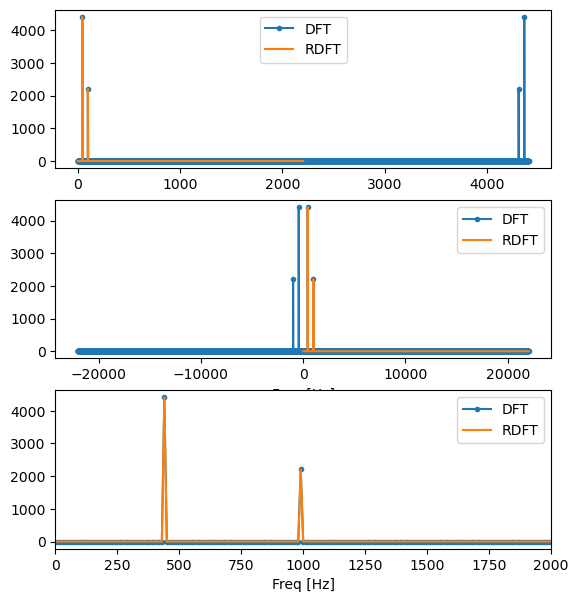

In [56]:
from scipy.fft import fft, fftfreq      # Full DFT
from scipy.fft import rfft, rfftfreq    # DFT for *real* input data 

# Generate the data 
freqs = [440,990]
t, signal = generate_signal( [2,1], freqs, [0,0], duration_seconds=0.1)

# Full DFT 
yf = fft(signal)
xf = fftfreq(signal.size, 1/44100 )
print(f'FFT.shape: {yf.shape} , x.shape:{xf.shape}')
# RDFT 
ryf = rfft(signal)
rxf = rfftfreq(signal.size, 1/44100 )
print(f'RFFT.shape: {ryf.shape} , rx.shape:{rxf.shape}')

# Make some plots ...
fig, (ax1, ax2, ax3) = plt.subplots(3)
fig.set_figheight(7)

ax1.plot(np.abs(yf), '.-', label='DFT')
ax1.plot(np.abs(ryf), label='RDFT')
ax1.legend()

ax2.plot(xf, np.abs(yf), '.-', label='DFT')
ax2.plot(rxf, np.abs(ryf), label='RDFT')
ax2.set_xlabel('Freq [Hz]')
ax2.legend()

ax3.plot(xf, np.abs(yf), '.-', label='DFT')
ax3.plot(rxf, np.abs(ryf), label='RDFT')
ax3.set_xlabel('Freq [Hz]')
ax3.set_xlim(0,2000)
ax3.legend()


# Exercise (B) 
1. Use the `generate_signal` function to generate a signal containing 3 frequency components 
2. Use the approach above to take the DFT using the `dft1D` function.
 - Use the `%%timeit` or `%timeit` "magic function" ([documentation link](https://ipython.readthedocs.io/en/stable/interactive/magics.html)) to time how long it takes to do this
3. Use the approach above to take the DFT using the `scipy.fft` function.
 - Use the `%%timeit` or `%timeit` "magic function" ([documentation link](https://ipython.readthedocs.io/en/stable/interactive/magics.html)) to time how long it takes to do this
4. Use the approach above to take the DFT using the `scipy.rfft` function.
 - Use the `%%timeit` or `%timeit` "magic function" ([documentation link](https://ipython.readthedocs.io/en/stable/interactive/magics.html)) to time how long it takes to do this
5. For (2), (3) & (4), plot the results of the DFT to check that everything is the same. 

# 4. FFT 
In Exercise (B), you should have seen that the `fft` & `rfft` functions from scipy are much much faster that the `dft1D` function we made above. 

There are a few reasons for this, but one of them is that Fast Fourier Transform algorithm ( see [link](https://en.wikipedia.org/wiki/Cooley%E2%80%93Tukey_FFT_algorithm)) is very clever and very efficient. 

To get an understanding of to improve the efficiency of the DFT, we can do the following rearrangement:

\begin{eqnarray}
X_{k} &=& \sum _{n=0}^{N-1}x_{n}\cdot e^{-{\frac {2\pi i}{N}}kn} \\ 
      &=& \sum _{m=0}^{N/2-1}x_{2m}\cdot e^{-{\frac {2\pi i}{N}}k(2m)} + 
          \sum _{m=0}^{N/2-1}x_{2m+1}\cdot e^{-{\frac {2\pi i}{N}}k(2m+1)} 
          \,\,\leftarrow\text{ splitting into even and odd indexed data-points} \\
      &=& \underbrace{\sum _{m=0}^{M-1}x_{2m}\cdot e^{-{\frac {2\pi i}{M}}km}}_{\text{Like a DFT, but k runs from 0 -to N-1}} + 
          e^{-{\frac{2\pi i}{N}}k} 
          \underbrace{\sum _{m=0}^{M-1}x_{2m+1}\cdot e^{-{\frac {2\pi i}{M}}km} }_{\text{Like a DFT, but k runs from 0 -to N-1}}
          \,\,\leftarrow\text{ $M\equiv N/2$}\\
\end{eqnarray}

**Consider the part of the summation with $k<M$:** 
 - By definition, this gives us a pair of half sized DFTs, which we will call $E_k$ and $O_k$, with  $E_k$ operating on the *even-indexed* data points, and $O_k$ operating on the *odd-indexed* data points. 
\begin{eqnarray}
X_{k\lt M} 
&=& \sum _{m=0}^{M-1}x_{2m}\cdot e^{-{\frac {2\pi i}{M}}km} + 
          e^{-{\frac{2\pi i}{N}}k} 
          \sum _{m=0}^{M-1}x_{2m+1}\cdot e^{-{\frac {2\pi i}{M}}km}
          \\
&=& E_k + e^{-{\frac{2\pi i}{N}}k} O_k
\end{eqnarray}


**Consider the other part of the summation, where $k \geq M$:**
 - Let's define $k=M+K$ (or $K=k-M$), 

\begin{eqnarray}
X_{k\geq M} 
&=& \sum _{m=0}^{M-1}x_{2m}\cdot e^{-{\frac {2\pi i}{M}}(M+K)m} + 
          e^{-{\frac{2\pi i}{N}}(M+K)} 
          \sum _{m=0}^{M-1}x_{2m+1}\cdot e^{-{\frac {2\pi i}{M}}(M+K)m}
          \,\,\leftarrow\text{ $k=M+K$}\\
&=& \sum _{m=0}^{M-1}x_{2m}\cdot e^{-{\frac {2\pi i}{M}}Km} + 
          e^{-{\frac{2\pi i}{N}}(M+K)} 
          \sum _{m=0}^{M-1}x_{2m+1}\cdot e^{-{\frac {2\pi i}{M}}Km}
          \,\,\leftarrow\text{ $e^{-2\pi i} \equiv 1$}\\
&=& \sum _{m=0}^{M-1}x_{2m}\cdot e^{-{\frac {2\pi i}{M}}Km} - 
          e^{-{\frac{2\pi i}{N}}(K)} 
          \sum _{m=0}^{M-1}x_{2m+1}\cdot e^{-{\frac {2\pi i}{M}}Km}
          \,\,\leftarrow\text{ $e^{ \frac{-2\pi i M}{N}} = e^{-\pi i} = -1$}\\
&=& \sum _{m=0}^{M-1}x_{2m}\cdot e^{-{\frac {2\pi i}{M}}(k-M)m} - 
          e^{-{\frac{2\pi i}{N}}(k-M)} 
          \sum _{m=0}^{M-1}x_{2m+1}\cdot e^{-{\frac {2\pi i}{M}}(k-M)m}
          \,\,\leftarrow\text{ $K=k-M$}\\
&=& E_{k-M} - e^{-{\frac{2\pi i}{N}}(k-M)} O_{k-M}
\end{eqnarray}


**Result**
\begin{eqnarray}
X_{k} &=& 
\begin{cases}
E_k + e^{-{\frac{2\pi i}{N}}k} O_k              \,\,\text{ if $k<N/2$} \\
E_{k-N/2} - e^{-{\frac{2\pi i}{N}}(k-N/2)} O_{k-N/2}  \,\,\text{ if $k\geq N/2$} 
\end{cases}
\end{eqnarray}




What we've done is express the DFT of length N recursively in terms of two DFTs of size N/2

We can then take these smaller DFT’s (e.g. $E_k) and split those down again into two even smaller DFT’s, and so on and so on.

If we only cared about computing a *single* frequency index, this reformulation wouldn’t help us, as the total number of calculations to be performed remains the same for a single frequency. 

The algorithm gains its speed by re-using the results of intermediate computations to compute multiple DFT outputs.


# 5. Audio files

See the following guides for more information 
 - https://docs.scipy.org/doc/scipy/reference/generated/scipy.io.wavfile.write.html
 - https://realpython.com/playing-and-recording-sound-python/#playing-audio-files

### Import `simpleaudio` package 
 - This package allows you to listen to audio files 
 - You may need to install this first on your machine: E.g. `pip install simpleaudio`


In [ ]:
import simpleaudio as sa

In [ ]:
wave_obj = sa.WaveObject.from_wave_file('CantinaBand3.wav')
play_obj = wave_obj.play()

### Use the `scipy` module, `wavfile` to import the "CantinaBand3.wav" file into python for analysis 

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.io import wavfile
sampFreq, sound = wavfile.read('CantinaBand3.wav')

In [ ]:
print(sampFreq, type(sampFreq))
print(sound, sound.dtype , sound.shape)
print(f'Sample Duration [seconds] = N_points / Freq = sound.shape[0]/sampFreq = {sound.shape[0]}/{sampFreq} = {sound.shape[0]/sampFreq}')
plt.plot(sound)

# Exercise (C)
 - Using your phone or laptop, record something (your voice, a sound, whatever), and save it as a '.wav' file
   --- https://recorder.easeus.com/screen-recording-tips/record-wav-file-on-windows.html#:~:text=Can%20I%20record%20a%20WAV,the%20sound%20format%20to%20WAV.
 - If you recorded it on your phone, copy the file onto your laptop
 - Import & play the wav file using the `simpleaudio` package 
 - Plot the waveform

###  Create a sound file from a `numpy` array 

 - Here we create a sine-wave using our `generate_signal` function
   - Note that the signal has a freq. = 440Hz, hence a period of oscillation of ~0.0023s 
   
 - Then we use the `map_to_16bit` function to convert the signal to a form acceptable by *.wav files
   - This requires *integers* in the range -32768:+32767
   
 - We then save the signal to file and play it using `simpleaudio`

In [ ]:
2**15 - 1

In [ ]:
# Generate a sine wave swith a freq of 440Hz using the `generate_signal` function (see Secn 3, above)
sample_freq_hertz = 44100
t, note = generate_signal( [1], [440], [0], duration_seconds=3.0, sample_freq_hertz = sample_freq_hertz)

# Plot a short section of the sine wave 
t_range = 440
plt.plot(t[:t_range], note[:t_range])
plt.show()

In [ ]:

def map_to_16bit( note_arr ):
    """ A function to map a signal to a form that can be saved as an audio *.wav file """

    # Ensure that highest value is in 16-bit range
    audio = note_arr * (2**15 - 1) / np.max(np.abs(note_arr))
    
    # Convert to 16-bit data
    audio = audio.astype(np.int16)

    return audio 

# map the sine wave amplitude to the values supported by 16-bit arrays
audio = map_to_16bit( note )

# Plot a short section of the sine wave 
plt.plot(t[:200], audio[:200])
plt.show()

In [ ]:
# Save the sine wave to file 
filename = 'sine_A.wav'
wavfile.write(filename, sample_freq_hertz, audio)

# Play the audio from file 
wave_obj = sa.WaveObject.from_wave_file(filename)
play_obj = wave_obj.play()

### Add together 2 different sine waves 

Here we make a signal with 2 components:
1. A signal with a freq. = 440Hz, hence a period of oscillation of ~0.0023s 
2. A signal with a freq. = 50Hz, and hence a *longer* period of oscillation of ~0.02s 

We choose to give the 50Hz signal a much larger amplitude. 

In [ ]:
# Generate a signal consisting of 2 sine waves at two different frequencies  
t, signal = generate_signal( [1,5], [440,50], [0,0], duration_seconds=3.0, sample_freq_hertz = sample_freq_hertz)

# Plot a short section of the sine waves 
t_range=1200
plt.plot(t[:t_range], signal[:t_range], label='signal')
plt.legend()
plt.show()

In the cell below, note that the `map_to_16bit` function has the effect of making all of the waves have the same total amplitude

In [ ]:
# map the sine wave amplitudes to the values supported by 16-bit arrays
audio = map_to_16bit( note )

# Plot a short section of the sine waves 
t_range=1500
plt.plot(t[:t_range], audio[:t_range], label='Audio')
plt.legend()
plt.show()

# Save the sine wave to file 
filename = 'sine_B.wav'
wavfile.write(filename, sample_freq_hertz, audio)

# Play the audio from file 
wave_obj = sa.WaveObject.from_wave_file(filename)
play_obj = wave_obj.play()

# Exercise (D)
 - Write a function, `generate_noisy_signal`, that will add "noise" to the signal generated by the `generate_signal` function. 
 - Your `generate_noisy_signal` function should accept the same arguments as `generate_signal`, and should call `generate_signal`, but then add some "noise" or "perturbation" to the signal that is returned from `generate_signal`.
   - Consider using `np.random.normal` as a source of noise ...
 - Plot the waveforms generated by `generate_signal` & `generate_noisy_signal` when they are given the same basic inputs 
 - Convert the waveforms generated by `generate_signal` & `generate_noisy_signal` to audio signals and save them to 2 different *.wav files (`d_pure.wav` & `d_noisy.way`) 
 - Play the two audio files 


# 6. Apply FFT to audio data ...

In [ ]:
from scipy.fft import fft, fftfreq

# Import 'pure' & 'noisy' data ( from Exercise D )... 
filename_pure = 'd_pure.wav'
sampFreq, sound_pure = wavfile.read(filename_pure)
y_pure = sound_pure
x_pure = np.arange(len(sound_pure))/sampFreq

filename_noisy = 'd_noisy.wav'
sampFreq, sound_noisy = wavfile.read(filename_noisy)
y_noisy = sound_noisy
x_noisy = np.arange(len(sound_noisy))/sampFreq

# Plot the data
plt.plot(x_pure, y_pure, '.-', label='pure')
plt.plot(x_noisy, y_noisy, '.-', label='noisy')
plt.xlim(0,0.01)
plt.legend()

When we take the DFT of the noisy data, we see that it has higher values across lots of frequencies than does the DFT of the pure data

In [ ]:
# Take the DFT
dft_pure = fft(y_pure)
dft_noisy = fft(y_noisy)

# Frequency vector ...
xf = fftfreq(sound_pure.size, 1/sampFreq )

# Plot the FT
# - NB: We have to use the `abs` function because the returned values are *complex* 
plt.plot(xf[:N//2], np.abs(dft_pure)[:N//2]*2/N , label=f'pure')
plt.plot(xf[:N//2], np.abs(dft_noisy)[:N//2]*2/N , label=f'noisy')
#plt.xlim(0,1000)
plt.yscale('log')
plt.legend()
plt.show()


##### Simply by filtering out (deleting) unwanted frequency components, we can clean up the audio ...

In [ ]:
# Get rid of any low amplitude signal in the noise DFT
# - Just setting most of the noisy values equal to zero 
dft_noisy_cleaned = np.copy(dft_noisy); dft_noisy_cleaned[np.abs(dft_noisy)*2/N < 1e3] = complex(0,0)

# Compare the DFT arrays 
plt.plot(xf[:N//2], np.abs(dft_pure)[:N//2]*2/N , '.-', label=f'pure')
plt.plot(xf[:N//2], np.abs(dft_noisy)[:N//2]*2/N , '.-',label=f'noisy')
plt.plot(xf[:N//2], np.abs(dft_noisy_cleaned)[:N//2]*2/N , label=f'noisy:cleaned')
plt.yscale('log')
plt.legend()
plt.show()


##### Take the inverse DFT to recover the signal in the time-domain


In [ ]:
from scipy.fft import ifft, fftfreq

# Take the Inverse-DFT
idft_pure = ifft(dft_pure)
idft_noisy = ifft(dft_noisy)
idft_noisy_cleaned = ifft(dft_noisy_cleaned)

# Plot the results of the inverse dtf
plt.plot(x_pure, idft_pure, '.-', label='pure')
plt.plot(x_pure, idft_noisy, '.-', label='noisy')
plt.plot(x_pure, idft_noisy_cleaned, '.-', label='noisy_cleaned')
plt.xlim(0,0.01)
plt.legend()

In [ ]:
# map the sine wave amplitudes to the values supported by 16-bit arrays
audio_pure = map_to_16bit( idft_pure )
audio_noisy = map_to_16bit( idft_noisy )
audio_noisy_cleaned = map_to_16bit( idft_noisy_cleaned )

# Save the audio to file 
filename_pure = 'idft_pure.wav'
wavfile.write(filename_pure, sample_freq_hertz, audio_pure)
filename_noisy = 'idft_noisy.wav'
wavfile.write(filename_noisy, sample_freq_hertz, audio_noisy)
filename_noisy_cleaned = 'idft_noisy_cleaned.wav'
wavfile.write(filename_noisy_cleaned, sample_freq_hertz, audio_noisy_cleaned)

# Play the audio from file 
wave_obj = sa.WaveObject.from_wave_file(filename_pure)
play_obj = wave_obj.play()

In [ ]:
# Play the audio from file 
wave_obj = sa.WaveObject.from_wave_file(filename_noisy)
play_obj = wave_obj.play()

In [ ]:
# Play the audio from file 
wave_obj = sa.WaveObject.from_wave_file(filename_noisy_cleaned)
play_obj = wave_obj.play()

# Unused

##### Components of the FT 
Now we consider the different components of the FT equation as applied to $f(x)=\cos\left(6\pi x\right)e^{-2 \pi x^2}$ to try and get some insight into its behavior.

\begin{eqnarray}
{\hat {f}}(\xi ) &=& \int _{-\infty }^{\infty }f(x) \exp^{-2\pi i\xi x}\,dx.
\\
                 &=& \int _{-\infty }^{\infty }f(x) \left(\cos \left(2\pi \xi x\right) - i\sin \left(2\pi \xi x\right) \right)\,dx.
\\
                 &=& \int _{-\infty }^{\infty } \left(\cos\left(6\pi x\right)e^{-2 \pi x^2}\right)  \left(\cos \left(2\pi \xi x\right) - i\sin \left(2\pi \xi x\right) \right)\,dx.                 
\\   
                &=& \int _{-\infty }^{\infty }R(x,\xi)\,dx - i \int _{-\infty }^{\infty }I(x,\xi)\,dx 
\end{eqnarray}
where we have split the integral up into real and imaginary parts, with the real integrand, $R(x,\xi)$, given by 

$R(x,\xi) = \left(\cos\left(6\pi x\right)e^{-2 \pi x^2}\right)  \cos \left(2\pi \xi x\right)$

and the imaginary integrand, $I(x,\xi)$, given by 

$I(x,\xi) = \left(\cos\left(6\pi x\right)e^{-2 \pi x^2}\right)  \sin \left(2\pi \xi x\right)$.

We define these as sympy functions in the cell below...

In [ ]:
x = sympy.Symbol('x')
xi = sympy.Symbol('xi')
def R(x, xi):
    return sympy.cos(6*sympy.pi*x ) * sympy.exp(-2*sympy.pi * x**2) * sympy.cos(2*sympy.pi*xi*x ) 
def I(x, xi):
    return sympy.cos(6*sympy.pi*x ) * sympy.exp(-2*sympy.pi * x**2) * sympy.sin(2*sympy.pi*xi*x ) 
